# Estimate the logical error rates of individual observables

The combined-basis quantum-memory notebook reports the probability that the decoder mispredicts *any* logical observable.
For a high-rate code that encodes many logical qubits, we may also want the error rate of each logical observable, or of each logical qubit.

Passing `count_observable_error_combos=True` to `sinter.collect` makes Sinter record, in `TaskStats.custom_counts`, how many shots mispredicted each combination of observables.
For example, the key `obs_mistake_mask=E_E__` counts shots in which the decoder mispredicted observables 0 and 2 and no others.

## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.

In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
from sympy.abc import x, y

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Build a combined-basis memory experiment

We use the $[[72,12,6]]$ bivariate bicycle code from [arXiv:2308.07915](https://arxiv.org/abs/2308.07915), which encodes $k=12$ logical qubits.
As in the combined-basis notebook, the memory experiment tracks all $2k=24$ logical observables, and the decoder handles the X and Z sectors separately.
Observables $0,\ldots,k-1$ are the X-type logical operators of the code, and observables $k,\ldots,2k-1$ are the Z-type logical operators.

In [3]:
code = codes.BBCode(
    {x: 6, y: 6},
    x**3 + y + y**2,
    y**3 + x + x**2,
)
num_logical_qubits = code.dimension
num_rounds = 6
physical_error_rate = 3e-3

parts = circuits.get_memory_experiment_parts(code, basis=None, num_rounds=num_rounds)
noise = circuits.DepolarizingNoiseModel(physical_error_rate, include_idling_error=False)
circuit = parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
assert circuit.num_observables == 2 * num_logical_qubits

decoder = decoders.SubgraphDecoder(
    (
        parts.detector_record.get_events(*parts.qubit_ids.checks_x),
        parts.detector_record.get_events(*parts.qubit_ids.checks_z),
    ),
    (
        range(num_logical_qubits),
        range(num_logical_qubits, 2 * num_logical_qubits),
    ),
    decoder=decoders.bp_lsd(
        max_iter=30,
        bp_method="ms",
        lsd_method="LSD_CS",
        lsd_order=0,
    ),
)

## Record which observables fail

The only change from an ordinary Sinter collection is `count_observable_error_combos=True`.

In [4]:
(stats,) = sinter.collect(
    tasks=[sinter.Task(circuit=circuit, decoder="bp_lsd")],
    custom_decoders={"bp_lsd": decoder},
    num_workers=NUM_WORKERS,
    max_shots=50_000,
    max_errors=500,
    count_observable_error_combos=True,
)

print(f"shots: {stats.shots}, shots with any observable mispredicted: {stats.errors}")
for key, count in stats.custom_counts.most_common(3):
    print(f"{count:4d}  {key}")

shots: 31300, shots with any observable mispredicted: 530
   6  obs_mistake_mask=__EEE___EE______________
   6  obs_mistake_mask=E_E__EEEEE______________
   5  obs_mistake_mask=_EEEE_EE__E_____________


## Marginalize the mistake masks

Character $j$ of a mask is `E` when the decoder mispredicted observable $j$.
The helper below counts the shots in which at least one observable in a group was mispredicted.
The group $\{j\}$ gives the failure count of observable $j$, and the group $\{j, j+k\}$ gives the failure count of logical qubit $j$.

In [5]:
def count_group_failures(
    stats: sinter.TaskStats, groups: Sequence[Sequence[int]]
) -> npt.NDArray[np.int_]:
    """Count shots in which any observable of each group was mispredicted."""
    group_counts = np.zeros(len(groups), dtype=int)
    for key, count in stats.custom_counts.items():
        mistakes = np.array([char == "E" for char in key.removeprefix("obs_mistake_mask=")])
        group_counts += count * np.array([mistakes[list(group)].any() for group in groups])
    return group_counts


def fit_rates(stats: sinter.TaskStats, hits: npt.NDArray[np.int_]) -> npt.NDArray[np.float64]:
    """Return rows (best, low, high) of binomial estimates for the given failure counts."""
    fits = [
        sinter.fit_binomial(
            num_shots=stats.shots, num_hits=int(num_hits), max_likelihood_factor=1000
        )
        for num_hits in hits
    ]
    return np.array([(fit.best, fit.low, fit.high) for fit in fits]).T


observable_hits = count_group_failures(stats, [[index] for index in range(2 * num_logical_qubits)])
qubit_hits = count_group_failures(
    stats, [[index, index + num_logical_qubits] for index in range(num_logical_qubits)]
)
assert count_group_failures(stats, [range(2 * num_logical_qubits)])[0] == stats.errors

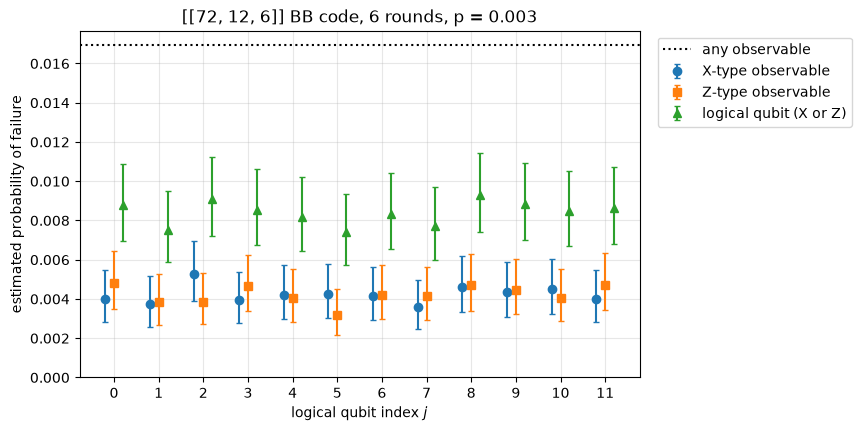

In [6]:
logical_indices = np.arange(num_logical_qubits)
aggregate_rate = stats.errors / stats.shots
series = {
    "X-type observable": fit_rates(stats, observable_hits[:num_logical_qubits]),
    "Z-type observable": fit_rates(stats, observable_hits[num_logical_qubits:]),
    "logical qubit (X or Z)": fit_rates(stats, qubit_hits),
}

figure, axis = plt.subplots(figsize=(8.5, 4.2), layout="constrained")
for offset, marker, (label, (best, low, high)) in zip(
    (-0.2, 0.0, 0.2), ("o", "s", "^"), series.items()
):
    axis.errorbar(
        logical_indices + offset,
        best,
        yerr=(best - low, high - best),
        fmt=marker,
        capsize=2,
        label=label,
    )
axis.axhline(aggregate_rate, color="black", linestyle=":", label="any observable")
axis.set_xticks(logical_indices)
axis.set_xlabel("logical qubit index $j$")
axis.set_ylabel("estimated probability of failure")
axis.set_title(f"[[72, 12, 6]] BB code, {num_rounds} rounds, p = {physical_error_rate:g}")
axis.set_ylim(bottom=0)
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
axis.grid(alpha=0.3)
plt.show()

## Correlated failures

A logical failure typically mispredicts several observables at once, so failures of different observables are strongly correlated, and the individual rates add up to more than the aggregate rate.

In [7]:
mean_mistakes = observable_hits.sum() / stats.errors
print(f"mean number of mispredicted observables per failed shot: {mean_mistakes:.1f}")

mean number of mispredicted observables per failed shot: 6.0
